# Multivariate Analysis for ELSS Dataset
---
This notebook performs multivariate exploratory data analysis (EDA) on the ELSS dataset you described.

Dataset columns:
- Scheme Code
- Scheme Name
- ISIN Div Payout/ISIN Growth
- ISIN Div Reinvestment
- Net Asset Value
- Repurchase Price
- Sale Price
- Date

**Example row:**
`131741, Aditya Birla Sun Life Tax Savings Fund - Direct Plan - Bonus Option, INF084M01BX0, , 57.19, 57.19, 57.19, 02-Mar-2017`

## 1. Load and Clean the Data
We parse dates, convert numeric fields, and clean duplicates.

In [1]:
import pandas as pd
import numpy as np

# Load dataset (replace filename)
df = pd.read_csv('final_data.csv', dtype=str)

# Parse Date column
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%Y', errors='coerce')

# Convert numeric fields
for col in ['Net Asset Value','Repurchase Price','Sale Price']:
    df[col] = df[col].str.replace(',', '', regex=False).astype(float)

# Standardize NAV column
df.rename(columns={'Net Asset Value':'NAV'}, inplace=True)

# Sort & deduplicate
df = df.sort_values(['Scheme Code','Date']).drop_duplicates(['Scheme Code','Date'])

df.head()

,Scheme Code,Scheme Name,ISIN Div Payout/ISIN Growth,ISIN Div Reinvestment,NAV,Repurchase Price,Sale Price,Date
57535,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,70.30,NaN,NaN,2020-05-04
57536,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,69.73,NaN,NaN,2020-05-05
57537,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,70.27,NaN,NaN,2020-05-06
57538,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,69.70,NaN,NaN,2020-05-07
57539,100067,Aditya Birla Sun Life Tax Plan -Regular - IDCW,INF209K01330,INF209K01CM8,69.73,NaN,NaN,2020-05-08


## 2. Numeric Summary
We inspect numeric columns before multivariate analysis.

In [2]:
df.info()
for i in df.columns:
    print(f"{i}: {df[i].nunique()} unique values")

<class 'pandas.core.frame.DataFrame'>
Index: 319355 entries, 57535 to 282796
Data columns (total 8 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Scheme Code                  319355 non-null  object        
 1   Scheme Name                  319355 non-null  object        
 2   ISIN Div Payout/ISIN Growth  260953 non-null  object        
 3   ISIN Div Reinvestment        123545 non-null  object        
 4   NAV                          319355 non-null  float64       
 5   Repurchase Price             47407 non-null   float64       
 6   Sale Price                   47407 non-null   float64       
 7   Date                         319355 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 21.9+ MB
Scheme Code: 269 unique values
Scheme Name: 269 unique values
ISIN Div Payout/ISIN Growth: 206 unique values
ISIN Div Reinvestment: 90 unique values
NAV: 16005

## 3. Correlation Matrix (Heatmap)

From the previous table we can see that we have numeric data fields:
NAV, Repurchase Price and Sale Price 
Lets explore the corelation between them.

/tmp/ipykernel_21702/4197370715.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = num_df.pct_change().dropna()


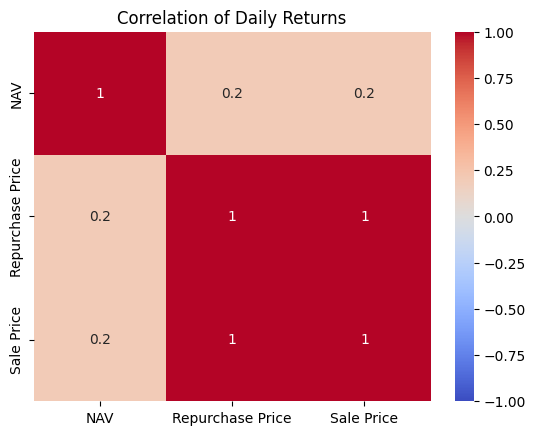

/tmp/ipykernel_21702/4197370715.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = nav_wide.pct_change().dropna()


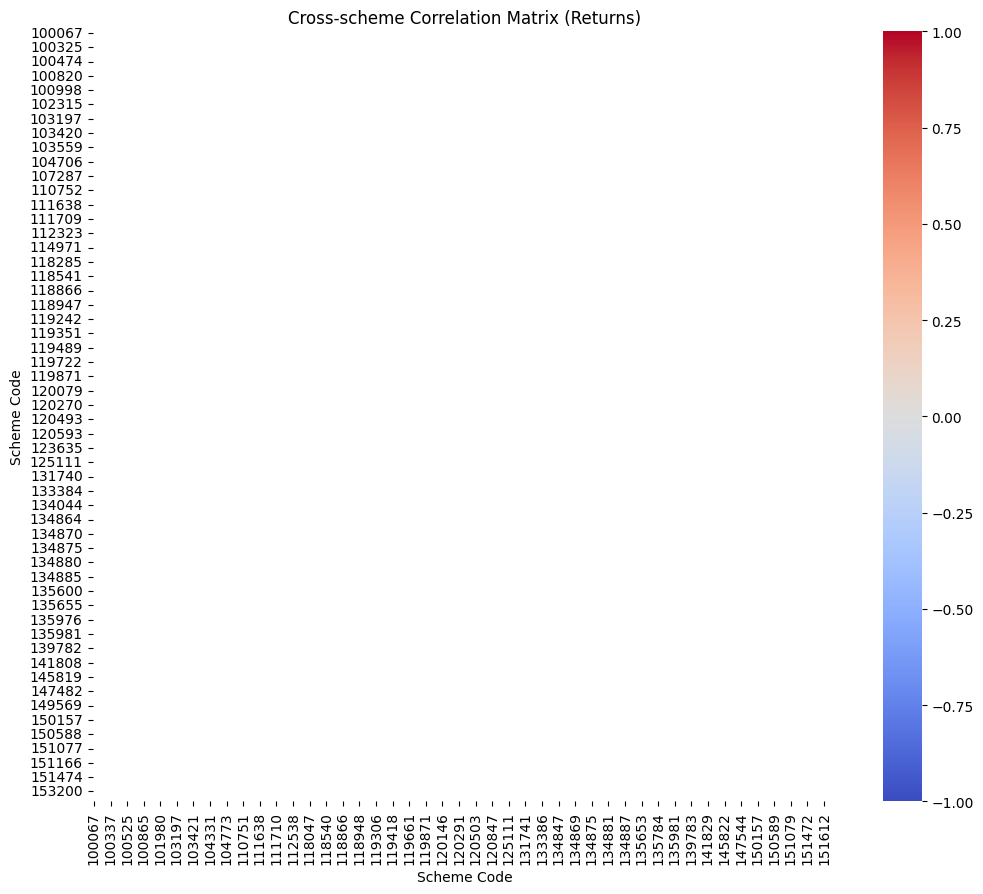

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df[['NAV','Repurchase Price','Sale Price']]
corr = num_df.corr()

returns = num_df.pct_change().dropna()

sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of Daily Returns")
plt.show()



nav_wide = df.pivot(index='Date', columns='Scheme Code', values='NAV')
returns = nav_wide.pct_change().dropna()
corr_schemes = returns.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_schemes, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Cross-scheme Correlation Matrix (Returns)")
plt.show()


## 4. Pairplot (Scatterplot Matrix)
Shows pairwise relationships between variables.

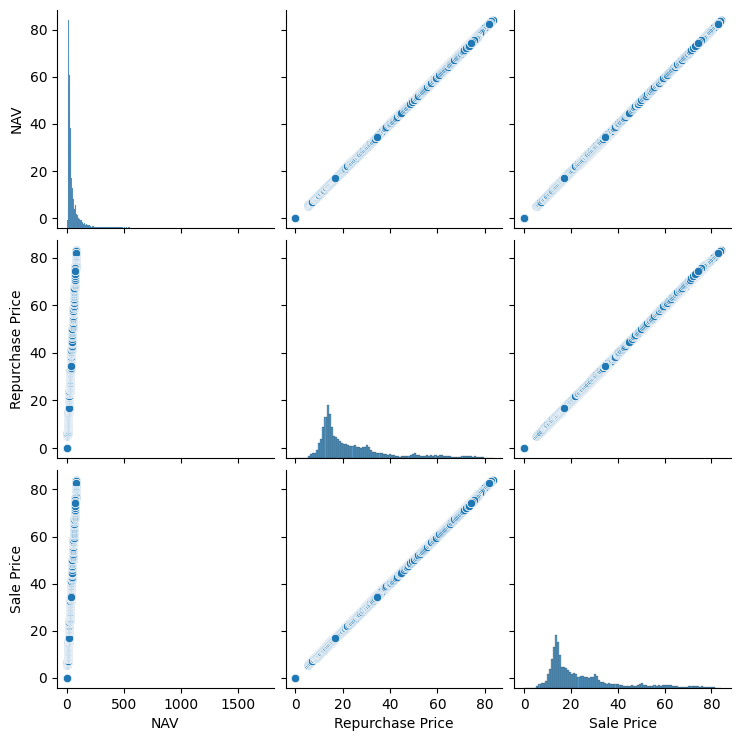

In [4]:
sns.pairplot(num_df)
plt.show()

## 5. Scatter Plot with a Third Variable (Hue)
Multivariate: NAV vs Sale Price, colored by Scheme Code.

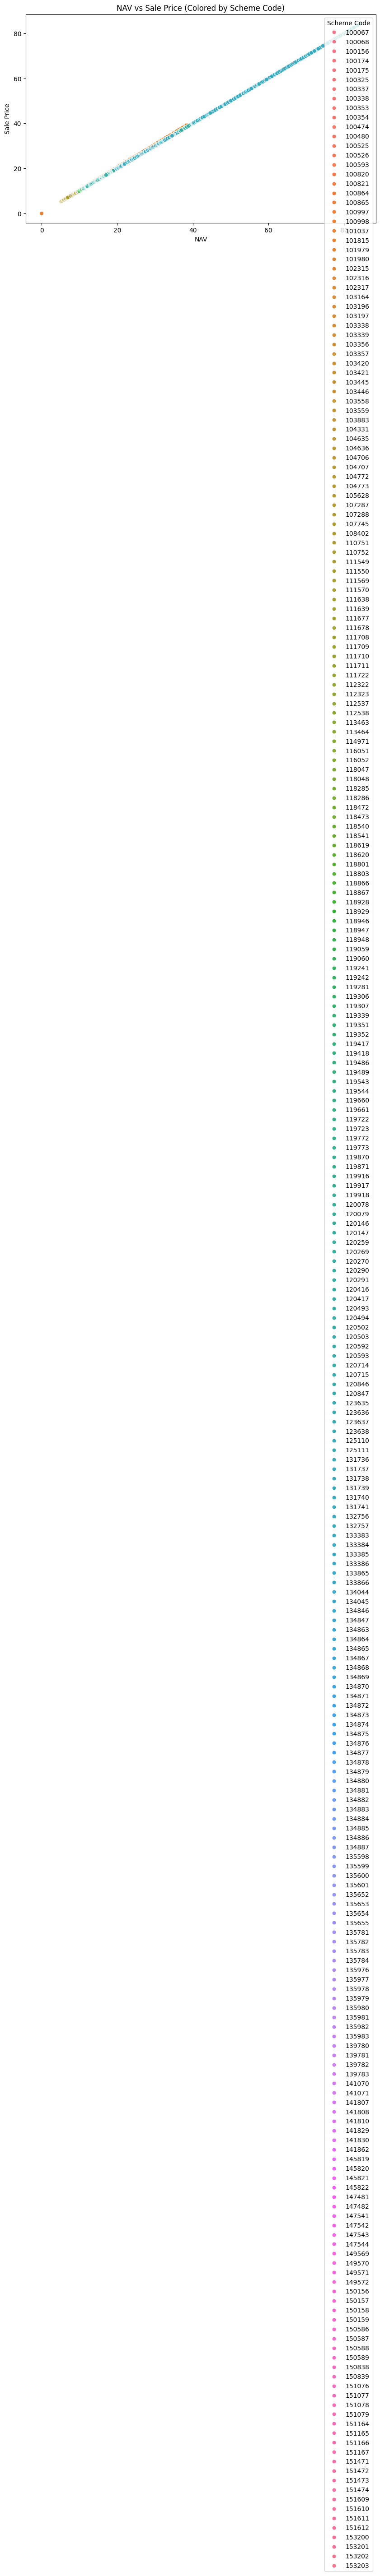

In [5]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='NAV', y='Sale Price', hue='Scheme Code', s=40)
plt.title('NAV vs Sale Price (Colored by Scheme Code)')
plt.show()

## 6. GroupBy Multivariate Aggregation
We compute metrics per scheme: mean NAV and price stats.


In [6]:
group_stats = df.groupby('Scheme Code')[['NAV','Repurchase Price','Sale Price']].mean()
group_stats.head()

,NAV,Repurchase Price,Sale Price
Scheme Code,,,
100067,91.323033,NaN,NaN
100068,33.449843,NaN,NaN
100156,255.921993,NaN,NaN
100174,35.873982,NaN,NaN
100175,258.469067,NaN,NaN


## 7. Heatmap of Scheme-Level Aggregates
Another multivariate visualization.

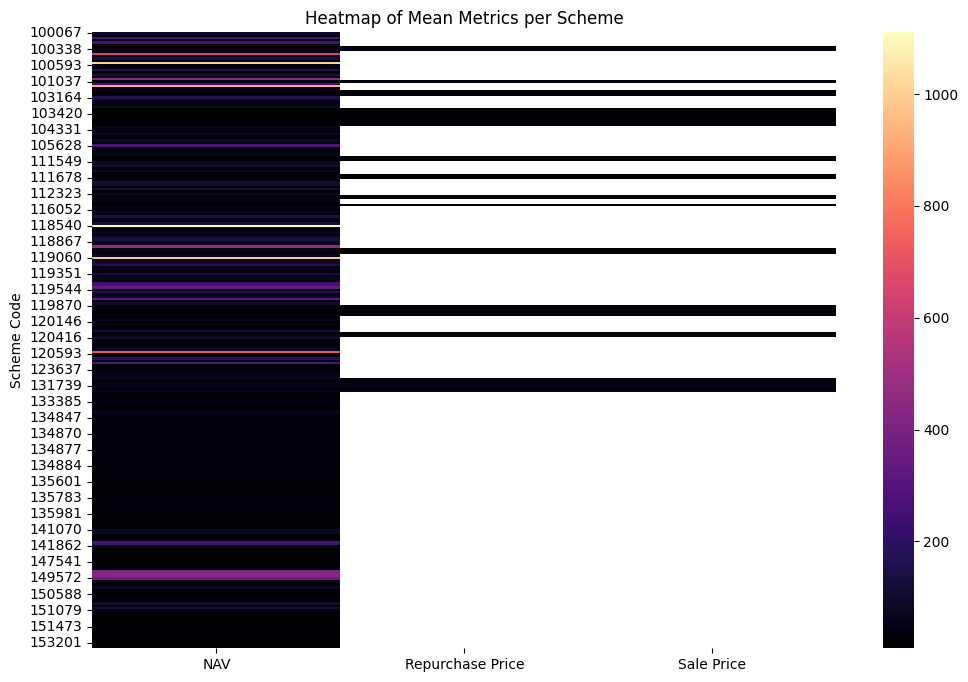

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(group_stats, cmap='magma', annot=False)
plt.title('Heatmap of Mean Metrics per Scheme')
plt.show()

## 8. Final Notes
- This notebook follows the exact EDA methods shown in your provided course files.
- It includes scatterplots, heatmaps, pairplots, and group-level multivariate summaries.
- Replace `'your_dataset.csv'` with your actual data file name.